In [63]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Basic data 

In [64]:
test_data = pd.read_csv('test.csv')
df = pd.read_csv('train.csv')

In [65]:
df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
421,422,20,RL,NaN,16635,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,215000
299,300,20,RL,80.0,14000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,8,2009,WD,Family,158500
1030,1031,190,RH,NaN,7082,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,160000
1436,1437,20,RL,60.0,9000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,5,2007,WD,Normal,120500
855,856,20,RL,NaN,6897,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,127000


In [66]:
df = df.iloc[:,1:]
df.shape

(1460, 80)

### Info on types

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

### Missing 

In [68]:
df.isnull().sum()[df.isnull().sum()>0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

### Numerical data 

In [69]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Duplicate

In [70]:
df.duplicated().sum()

np.int64(0)

### Correlation

In [71]:
corr = df.corr(numeric_only="True")

## Numeric

In [72]:
corr['SalePrice'].sort_values(ascending=False)
## Done with numerical relations

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

Top correlated features:

GrLivArea
TotalBsmtSF
GarageArea
1stFlrSF

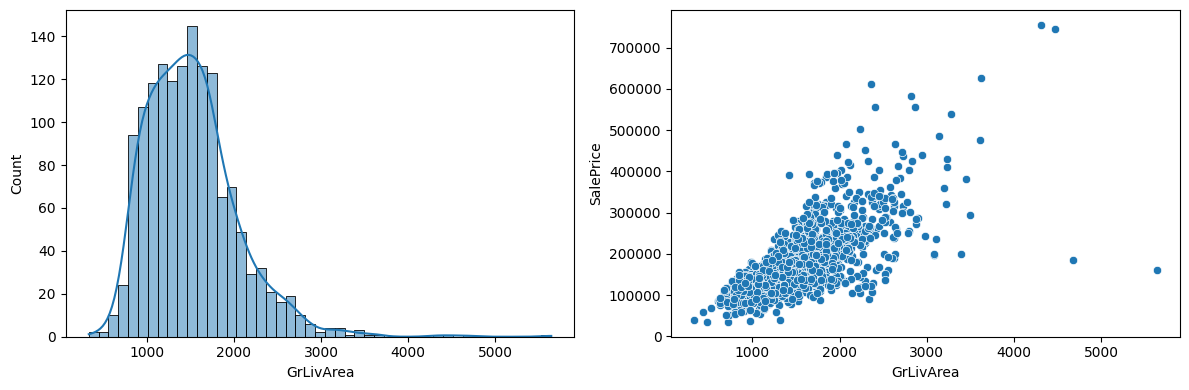

In [100]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(x=df['GrLivArea'], kde=True, ax=ax[0])
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'], ax=ax[1])
plt.tight_layout()
plt.show()

GrLivArea:
- positively correlated with SalePrice
- right skewed
- few extreme outliers
- mostly linear relationship

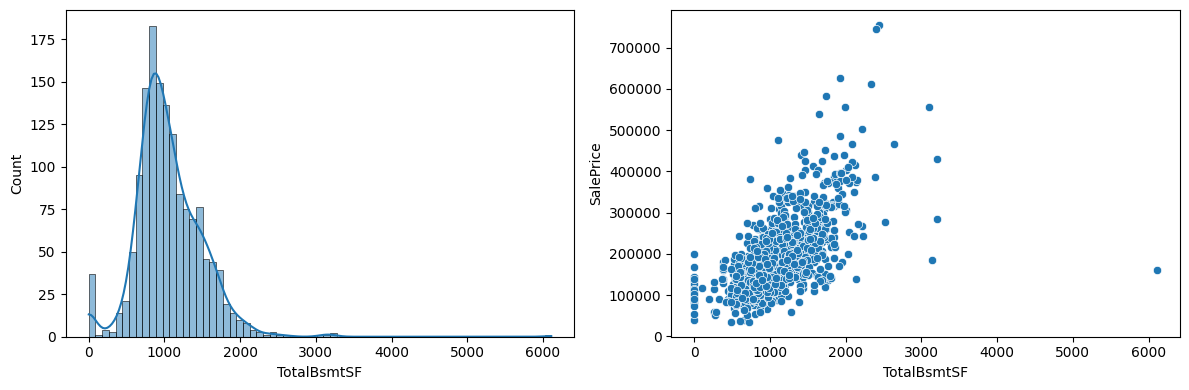

In [85]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(x=df['TotalBsmtSF'], kde=True, ax=ax[0])
sns.scatterplot(x=df['TotalBsmtSF'], y=df['SalePrice'], ax=ax[1])
plt.tight_layout()
plt.show()

TotalBsmtSF:
- positively correlated with SalePrice
- right skewed
- avg number extreme outliers because of not having it 
- mostly linear relationship

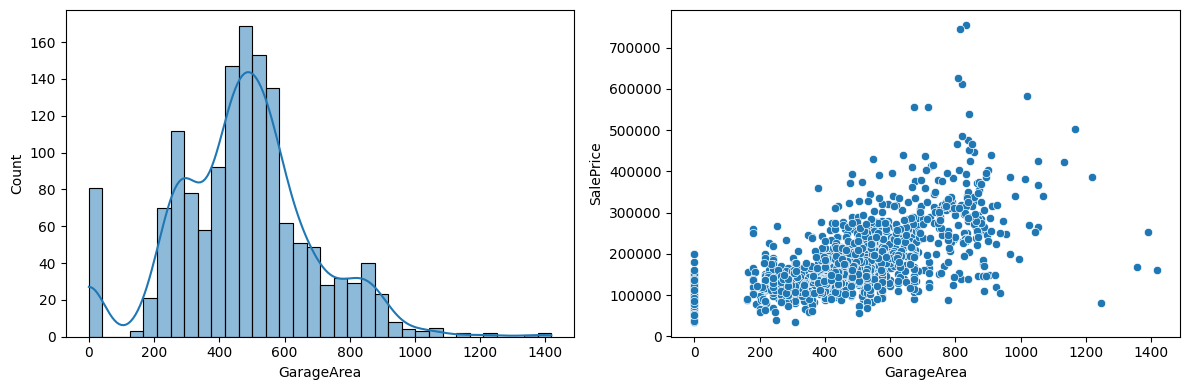

In [86]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(x=df['GarageArea'], kde=True, ax=ax[0])
sns.scatterplot(x=df['GarageArea'], y=df['SalePrice'], ax=ax[1])
plt.tight_layout()
plt.show()

GarageArea:
- positively correlated with SalePrice
- moderate spread in data points
- houses with similar garage areas can have varying prices
- relationship is positive but less tightly clustered

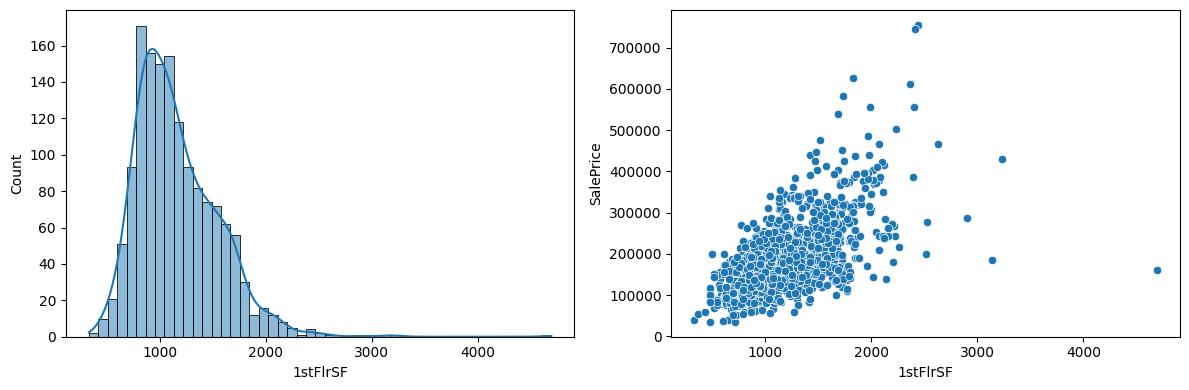

In [87]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(x=df['1stFlrSF'], kde=True, ax=ax[0])
sns.scatterplot(x=df['1stFlrSF'], y=df['SalePrice'], ax=ax[1])
plt.tight_layout()
plt.show()

1stFlrSF:
- positively correlated with SalePrice
- right skewed
- very few outliners
- mostly linear relationship

### 1/5th data quick review

In [74]:
# from ydata_profiling import ProfileReport
# profile = ProfileReport(df, explorative=True)
# profile.to_file("report.html")

Among explored numeric features, GrLivArea appears to have the strongest and most consistent relationship with SalePrice.

## Category

things like pool, garage, kitchen and all conditions come in overalqual <br><br>
alley has a lot of missing so skip<br><br>
PoolQC          1453<br>
Fence           1179<br>
MiscFeature     1406<br><br>
misisnf means not exist so skip for now <br><br>
mmsubclass should matterlandcouter later not major <br><br>
neighbourhood should over codition1 and 2 , dwelling<br><br>
if using overall qual, overall condn shouldnt effect much <br><br>
or maybe use both so year built and all wont matter <br><br>


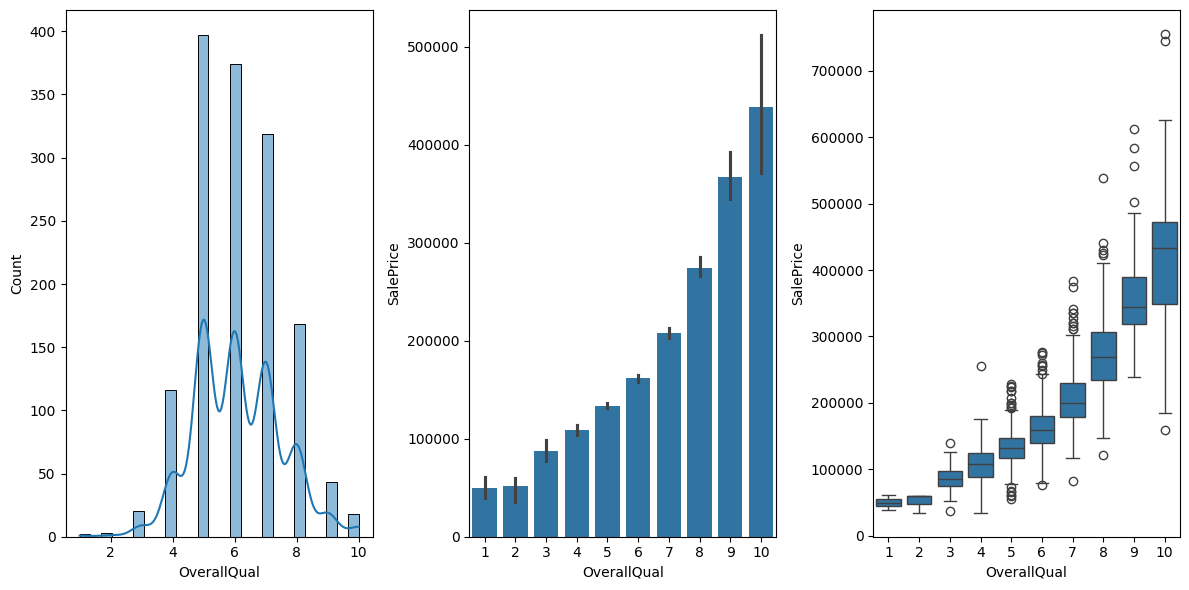

In [90]:
fig, ax = plt.subplots(1,3, figsize=(12,6))
sns.histplot(x=df['OverallQual'], kde=True, ax=ax[0])
sns.barplot(x=df['OverallQual'], y=df['SalePrice'], ax=ax[1])
sns.boxplot(x=df['OverallQual'], y=df['SalePrice'], ax=ax[2])
plt.tight_layout()
plt.show()

OverallQual:
- linear relationship 
- in boxplot 5,6,7 rating houses have many outliners (most houses probably fall in mid-quality range
larger sample size naturally creates more variation)

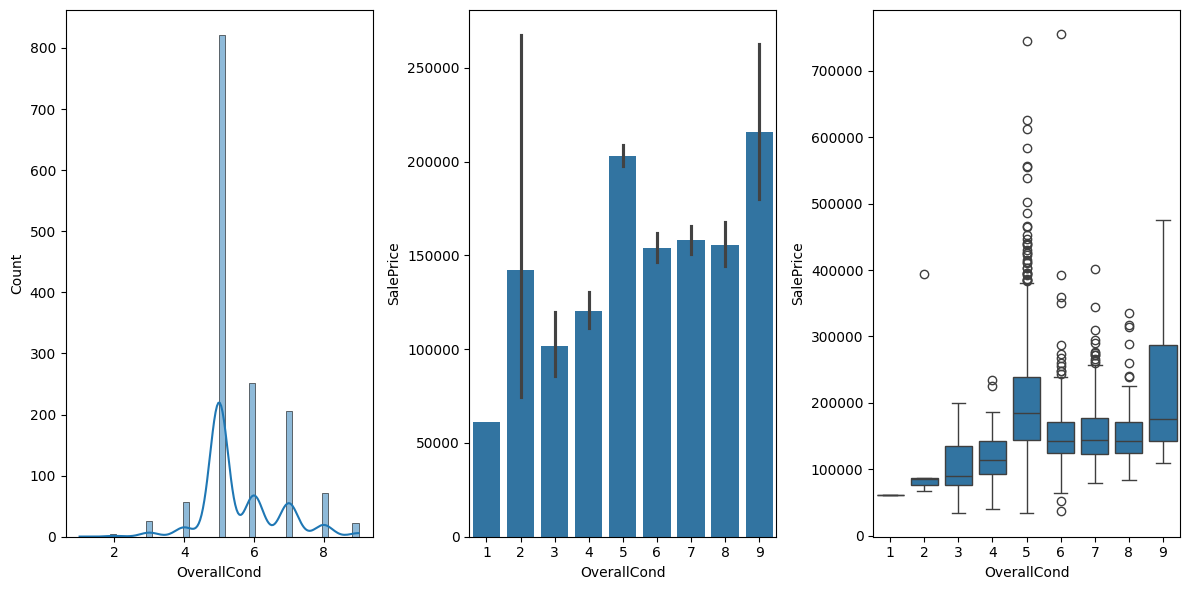

In [91]:
fig, ax = plt.subplots(1,3, figsize=(12,6))
sns.histplot(x=df['OverallCond'], kde=True, ax=ax[0])
sns.barplot(x=df['OverallCond'], y=df['SalePrice'], ax=ax[1])
sns.boxplot(x=df['OverallCond'], y=df['SalePrice'], ax=ax[2])
plt.tight_layout()
plt.show()

In [95]:
df[['OverallCond', 'OverallQual']].corr()

,OverallCond,OverallQual
OverallCond,1.000000,-0.091932
OverallQual,-0.091932,1.000000


OverallCondn
- 5 rating house has lot of outlinears otherwise pretty linear
- Not correlated with quality 

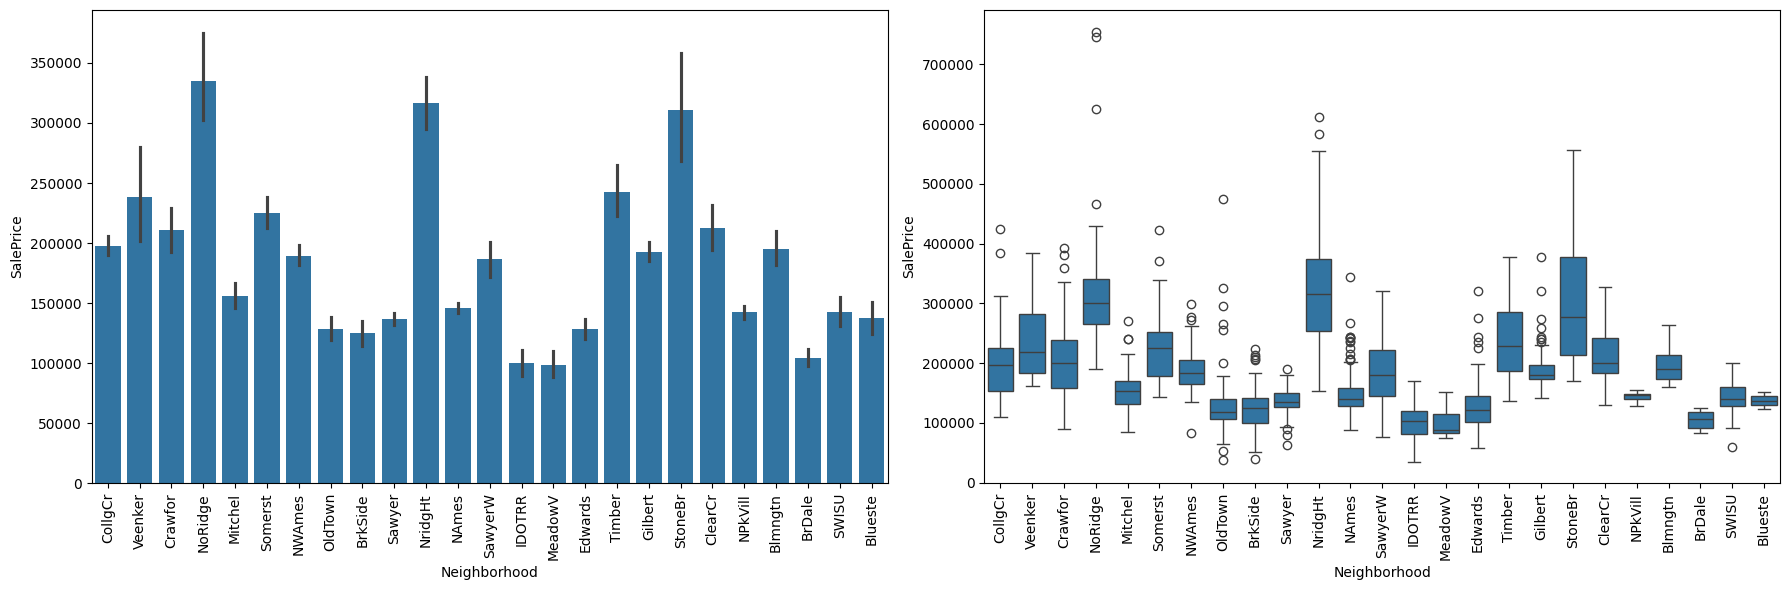

In [101]:
fig, ax = plt.subplots(1, 2, figsize=(18,6))

sns.barplot(
    x=df['Neighborhood'],
    y=df['SalePrice'],
    ax=ax[0]
)

sns.boxplot(
    x=df['Neighborhood'],
    y=df['SalePrice'],
    ax=ax[1]
)

for a in ax:
    a.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Neightbourhood:
- Not many outlinrs in each category 
- Median values have significant diff

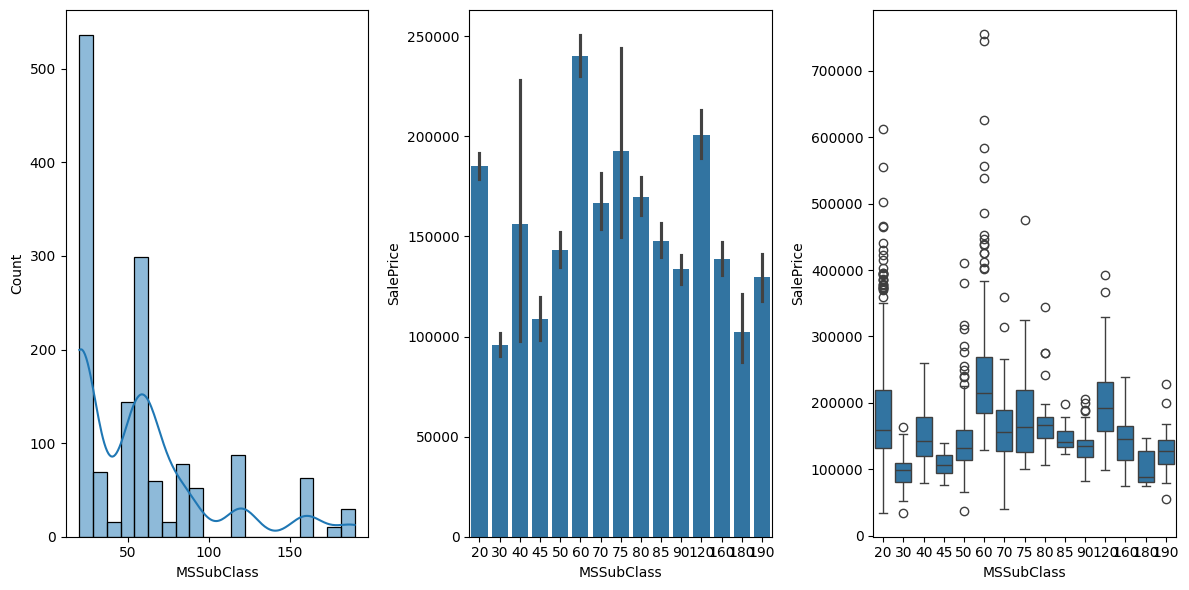

In [97]:
fig, ax = plt.subplots(1,3, figsize=(12,6))
sns.histplot(x=df['MSSubClass'], kde=True, ax=ax[0])
sns.barplot(x=df['MSSubClass'], y=df['SalePrice'], ax=ax[1])
sns.boxplot(x=df['MSSubClass'], y=df['SalePrice'], ax=ax[2])
plt.tight_layout()
plt.show()

MMSubclass
- lot of outlinears in class 20 and 60 
- most houses probably fall in mid-quality range
larger sample size naturally creates more variation